# ... 3 ...

# Offloading a flow

In [1]:
from cosim import Flow, Flowdb, Infra, Infradb, Utility, Policy
import random

### Requires infra

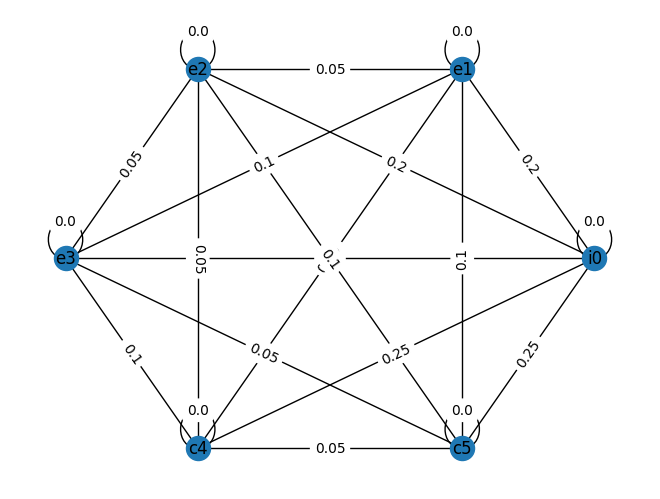

Node i0:{'rate': 5.0}
Node e1:{'rate': 2.0}
Node e2:{'rate': 2.0}
Node e3:{'rate': 2.0}
Node c4:{'rate': 1.0}
Node c5:{'rate': 1.0}
Edge ('i0', 'i0'):{'rate': 0.0}
Edge ('i0', 'e1'):{'rate': 0.2}
Edge ('i0', 'e2'):{'rate': 0.2}
Edge ('i0', 'e3'):{'rate': 0.2}
Edge ('i0', 'c4'):{'rate': 0.25}
Edge ('i0', 'c5'):{'rate': 0.25}
Edge ('e1', 'e1'):{'rate': 0.0}
Edge ('e1', 'e2'):{'rate': 0.05}
Edge ('e1', 'e3'):{'rate': 0.1}
Edge ('e1', 'c4'):{'rate': 0.05}
Edge ('e1', 'c5'):{'rate': 0.1}
Edge ('e2', 'e2'):{'rate': 0.0}
Edge ('e2', 'e3'):{'rate': 0.05}
Edge ('e2', 'c4'):{'rate': 0.05}
Edge ('e2', 'c5'):{'rate': 0.1}
Edge ('e3', 'e3'):{'rate': 0.0}
Edge ('e3', 'c4'):{'rate': 0.1}
Edge ('e3', 'c5'):{'rate': 0.05}
Edge ('c4', 'c4'):{'rate': 0.0}
Edge ('c4', 'c5'):{'rate': 0.05}
Edge ('c5', 'c5'):{'rate': 0.0}


In [2]:
infra_name = 'infra_2'
infra = Infra(Infradb.Get(infra_name), Effective=True)
infra.render()
print(infra)

### Requires infra instance (randomization)

In [3]:

infra = infra * [random.randint(5, 19)/10 for _ in infra.nodes] # set task rates
infra = infra / [random.randint(15, 99)/100 for _ in infra.edges] # set data rates
print(infra)

Node i0:{'rate': 1.1}
Node e1:{'rate': 1.5}
Node e2:{'rate': 1.5}
Node e3:{'rate': 0.9}
Node c4:{'rate': 1.8}
Node c5:{'rate': 1.5}
Edge ('i0', 'i0'):{'rate': 0.31}
Edge ('i0', 'e1'):{'rate': 0.61}
Edge ('i0', 'e2'):{'rate': 0.27}
Edge ('i0', 'e3'):{'rate': 0.66}
Edge ('i0', 'c4'):{'rate': 0.33}
Edge ('i0', 'c5'):{'rate': 0.39}
Edge ('e1', 'e1'):{'rate': 0.79}
Edge ('e1', 'e2'):{'rate': 0.83}
Edge ('e1', 'e3'):{'rate': 0.48}
Edge ('e1', 'c4'):{'rate': 0.89}
Edge ('e1', 'c5'):{'rate': 0.84}
Edge ('e2', 'e2'):{'rate': 0.25}
Edge ('e2', 'e3'):{'rate': 0.26}
Edge ('e2', 'c4'):{'rate': 0.73}
Edge ('e2', 'c5'):{'rate': 0.92}
Edge ('e3', 'e3'):{'rate': 0.25}
Edge ('e3', 'c4'):{'rate': 0.79}
Edge ('e3', 'c5'):{'rate': 0.83}
Edge ('c4', 'c4'):{'rate': 0.66}
Edge ('c4', 'c5'):{'rate': 0.77}
Edge ('c5', 'c5'):{'rate': 0.17}


### Requires flow

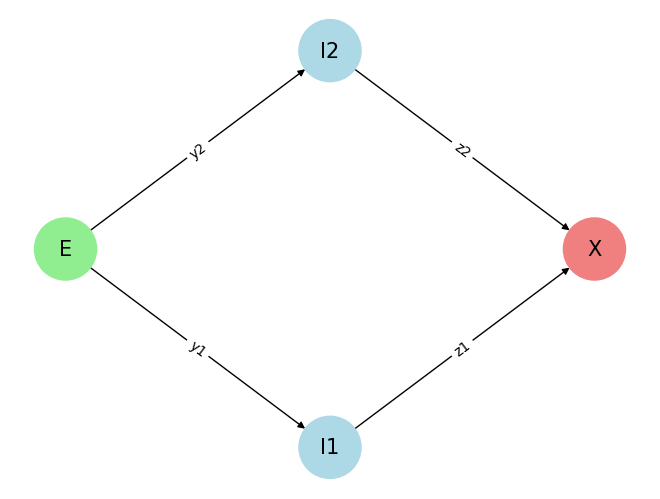

Node E:{'inputs': ('x',), 'outputs': ('y1', 'y2'), 'size': 0.0, 'decision': None, 'subset': 0}
Node I1:{'inputs': ('y1',), 'outputs': ('z1',), 'size': 0.0, 'decision': None, 'subset': 1}
Node I2:{'inputs': ('y2',), 'outputs': ('z2',), 'size': 0.0, 'decision': None, 'subset': 1}
Node X:{'inputs': ('z1', 'z2'), 'outputs': ('o',), 'size': 0.0, 'decision': None, 'subset': 2}
Edge ('E', 'I1'):{'data': 'y1', 'size': 0.0}
Edge ('E', 'I2'):{'data': 'y2', 'size': 0.0}
Edge ('I1', 'X'):{'data': 'z1', 'size': 0.0}
Edge ('I2', 'X'):{'data': 'z2', 'size': 0.0}


In [4]:
flow_name = 'flow_2'
flow = Flow(flow_name, **Flowdb.Get(flow_name))
flow.render(drawargs=dict(font_size=15, node_size=2000), edge_labels=True, layout='multipartite_layout', )
print(flow)

### Requires flow instance

In [5]:

flow = flow * [random.randint(5, 19) for _ in flow.nodes] # set task sizes
flow = flow / [random.randint(15, 99) for _ in flow.edges] # set data sizes
print(flow)

Node E:{'inputs': ('x',), 'outputs': ('y1', 'y2'), 'size': 10.0, 'decision': None, 'subset': 0}
Node I1:{'inputs': ('y1',), 'outputs': ('z1',), 'size': 5.0, 'decision': None, 'subset': 1}
Node I2:{'inputs': ('y2',), 'outputs': ('z2',), 'size': 18.0, 'decision': None, 'subset': 1}
Node X:{'inputs': ('z1', 'z2'), 'outputs': ('o',), 'size': 18.0, 'decision': None, 'subset': 2}
Edge ('E', 'I1'):{'data': 'y1', 'size': 58.0}
Edge ('E', 'I2'):{'data': 'y2', 'size': 88.0}
Edge ('I1', 'X'):{'data': 'z1', 'size': 54.0}
Edge ('I2', 'X'):{'data': 'z2', 'size': 24.0}


### Define decision policy

In [6]:
decisions = []

decisions += [Policy.FixedNode(flow, infra, i) for i in range(len(infra.NODES))]

#decisions += [Policy.Random(flow, infra) for _ in range(100)]

#decisions += [Policy.RandomOffload(flow, infra) for I in range(100)]

print(len(decisions))
decisions

6


[{'E': 'i0', 'I1': 'i0', 'I2': 'i0', 'X': 'i0'},
 {'E': 'i0', 'I1': 'e1', 'I2': 'e1', 'X': 'i0'},
 {'E': 'i0', 'I1': 'e2', 'I2': 'e2', 'X': 'i0'},
 {'E': 'i0', 'I1': 'e3', 'I2': 'e3', 'X': 'i0'},
 {'E': 'i0', 'I1': 'c4', 'I2': 'c4', 'X': 'i0'},
 {'E': 'i0', 'I1': 'c5', 'I2': 'c5', 'X': 'i0'}]

### Requires decision

In [7]:
for decision in decisions:
    flow = flow + decision # set decision
    cost, path = Utility.Cost(flow, infra)
    print(decision.values(), cost, path)


dict_values(['i0', 'i0', 'i0', 'i0']) 65.52000000000001 ['E', 'I2', 'X']
dict_values(['i0', 'e1', 'e1', 'i0']) 106.32000000000001 ['E', 'I2', 'X']
dict_values(['i0', 'e2', 'e2', 'i0']) 68.24000000000001 ['E', 'I2', 'X']
dict_values(['i0', 'e3', 'e3', 'i0']) 101.12 ['E', 'I2', 'X']
dict_values(['i0', 'c4', 'c4', 'i0']) 80.36000000000001 ['E', 'I2', 'X']
dict_values(['i0', 'c5', 'c5', 'i0']) 81.68 ['E', 'I2', 'X']


In [8]:
total_sols = Utility.Solutions(flow, infra, fix=1+1)
total_sols

36

In [9]:
raise ValueError

ValueError: 

## Feasible

In [10]:
sols = Utility.Enumerate(flow, infra, fixl=1, fixr=1)

y = []
for i,s in enumerate(sols):
    flow = flow + s # set decision
    cost, path = Utility.Cost(flow, infra)
    y.append(cost)
    print(s, cost, path)

x = list(range(len(sols)))


['i0', 'i0', 'i0', 'i0'] 65.52000000000001 ['E', 'I2', 'X']
['i0', 'e1', 'i0', 'i0'] 86.82 ['E', 'I1', 'X']
['i0', 'e2', 'i0', 'i0'] 65.52000000000001 ['E', 'I2', 'X']
['i0', 'e3', 'i0', 'i0'] 89.42 ['E', 'I1', 'X']
['i0', 'c4', 'i0', 'i0'] 65.52000000000001 ['E', 'I2', 'X']
['i0', 'c5', 'i0', 'i0'] 65.52000000000001 ['E', 'I2', 'X']
['i0', 'i0', 'e1', 'i0'] 106.32000000000001 ['E', 'I2', 'X']
['i0', 'e1', 'e1', 'i0'] 106.32000000000001 ['E', 'I2', 'X']
['i0', 'e2', 'e1', 'i0'] 106.32000000000001 ['E', 'I2', 'X']
['i0', 'e3', 'e1', 'i0'] 106.32000000000001 ['E', 'I2', 'X']
['i0', 'c4', 'e1', 'i0'] 106.32000000000001 ['E', 'I2', 'X']
['i0', 'c5', 'e1', 'i0'] 106.32000000000001 ['E', 'I2', 'X']
['i0', 'i0', 'e2', 'i0'] 68.24000000000001 ['E', 'I2', 'X']
['i0', 'e1', 'e2', 'i0'] 86.82 ['E', 'I1', 'X']
['i0', 'e2', 'e2', 'i0'] 68.24000000000001 ['E', 'I2', 'X']
['i0', 'e3', 'e2', 'i0'] 89.42 ['E', 'I1', 'X']
['i0', 'c4', 'e2', 'i0'] 68.24000000000001 ['E', 'I2', 'X']
['i0', 'c5', 'e2', 'i0

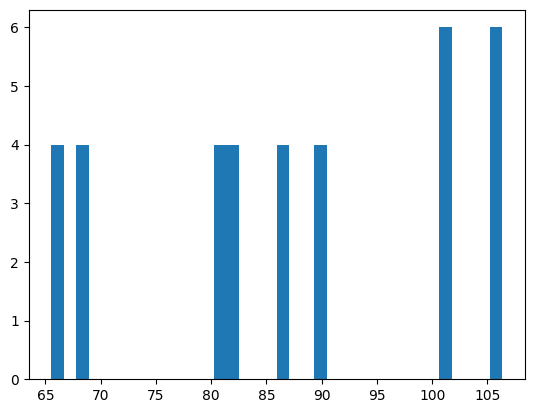

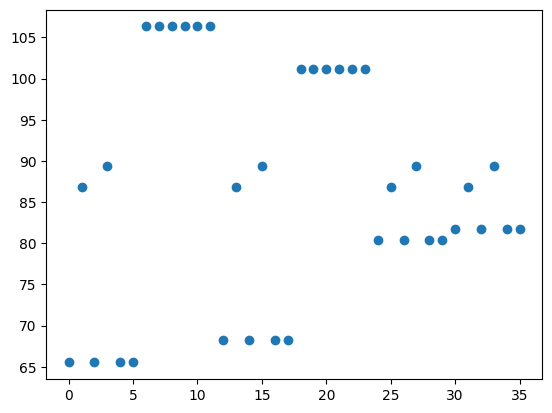

Min Cost: 65.52000000000001 (4 of 36, Prob = 0.1111111111111111)
Avg Cost: 87.02222222222225
Max Cost: 106.32000000000001 (6 of 36, Prob = 0.16666666666666666)
['i0', 'i0', 'i0', 'i0'] 65.52000000000001
['i0', 'e2', 'i0', 'i0'] 65.52000000000001
['i0', 'c5', 'i0', 'i0'] 65.52000000000001
['i0', 'c4', 'i0', 'i0'] 65.52000000000001
['i0', 'i0', 'e2', 'i0'] 68.24000000000001
['i0', 'e2', 'e2', 'i0'] 68.24000000000001
['i0', 'c5', 'e2', 'i0'] 68.24000000000001
['i0', 'c4', 'e2', 'i0'] 68.24000000000001
['i0', 'i0', 'c4', 'i0'] 80.36000000000001
['i0', 'e2', 'c4', 'i0'] 80.36000000000001
['i0', 'c5', 'c4', 'i0'] 80.36000000000001
['i0', 'c4', 'c4', 'i0'] 80.36000000000001
['i0', 'i0', 'c5', 'i0'] 81.68
['i0', 'c5', 'c5', 'i0'] 81.68
['i0', 'c4', 'c5', 'i0'] 81.68
['i0', 'e2', 'c5', 'i0'] 81.68
['i0', 'e1', 'c5', 'i0'] 86.82
['i0', 'e1', 'c4', 'i0'] 86.82
['i0', 'e1', 'i0', 'i0'] 86.82
['i0', 'e1', 'e2', 'i0'] 86.82
['i0', 'e3', 'c5', 'i0'] 89.42
['i0', 'e3', 'c4', 'i0'] 89.42
['i0', 'e3', '

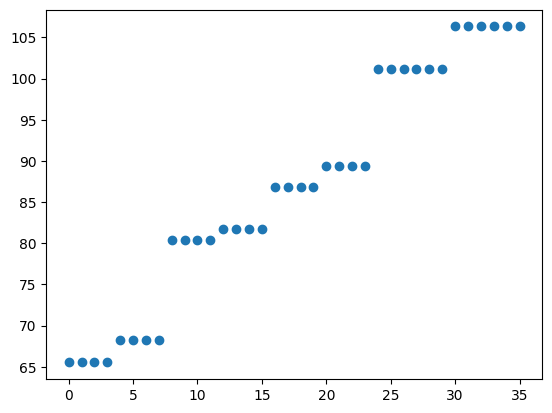

In [11]:
import numpy as np

import matplotlib.pyplot as plt

plt.hist(y, bins=len(sols))
plt.show()
plt.scatter(x,y)
plt.show()


yy = np.array(y)
yi = np.argsort(yy)
xx = [sols[i] for i in yi]
yy = yy[yi]

miny = yy[0]
maxy = yy[-1]
meany = np.mean(yy)

min_count = len(np.where((yy==miny))[0])
max_count = len(np.where((yy==maxy))[0])
min_prob = min_count/total_sols
max_prob = max_count/total_sols

print(f'Min Cost: {miny} ({min_count} of {total_sols}, Prob = {min_prob})')
print(f'Avg Cost: {meany}')
print(f'Max Cost: {maxy} ({max_count} of {total_sols}, Prob = {max_prob})')


for i,j in zip(xx, yy):
    print(i,j)
plt.scatter(x,yy)




